<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Calories_Burnt_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install optuna

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import cross_val_score

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso

import optuna
warnings.filterwarnings('ignore')
#

In [6]:
df=pd.read_csv('calories.csv')

In [7]:
target="Calories"

In [8]:
df.sample(5)

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
175,19584135,female,40,157.0,61.0,12.0,92.0,40.0,58.0
12999,17312213,female,71,172.0,69.0,21.0,108.0,40.3,146.0
10038,18668213,female,21,166.0,62.0,26.0,108.0,40.9,161.0
6682,18471107,male,54,195.0,96.0,12.0,90.0,39.9,61.0
14037,12127647,male,20,177.0,77.0,2.0,90.0,38.6,6.0


In [9]:
df.isnull().sum()

,0
User_ID,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0
Calories,0


In [10]:
df.describe()

,User_ID,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


**EDA**

In [11]:
numeric_df = df.select_dtypes(include=[np.number])

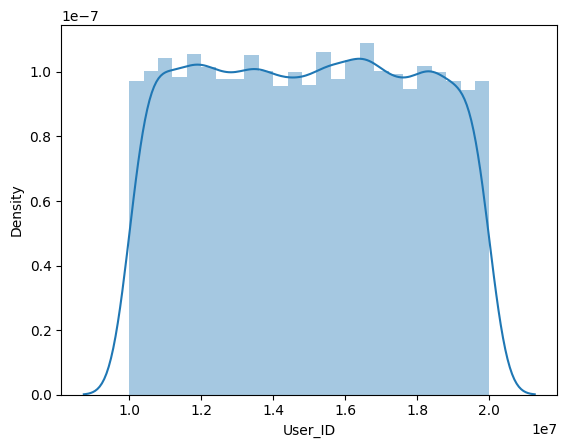

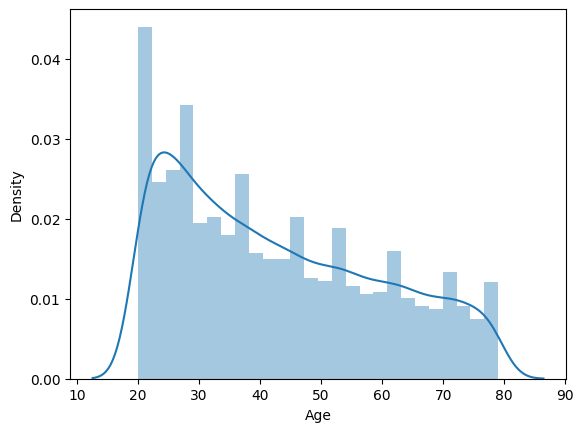

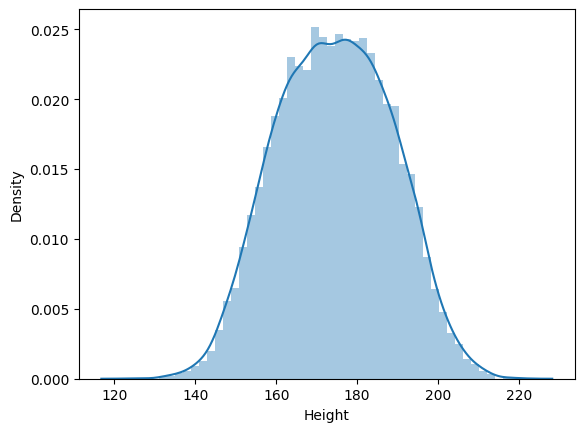

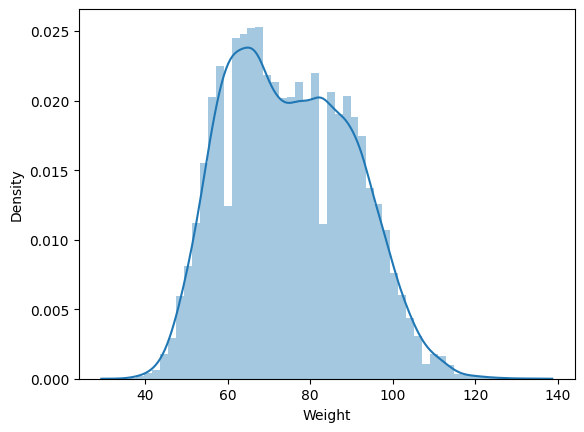

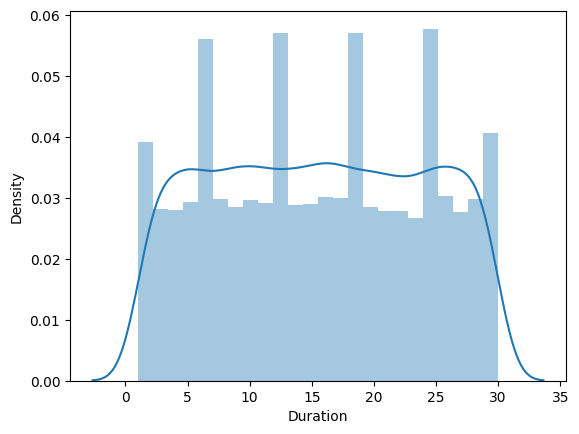

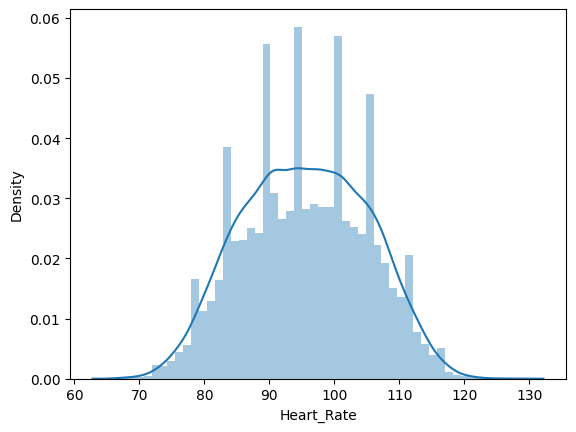

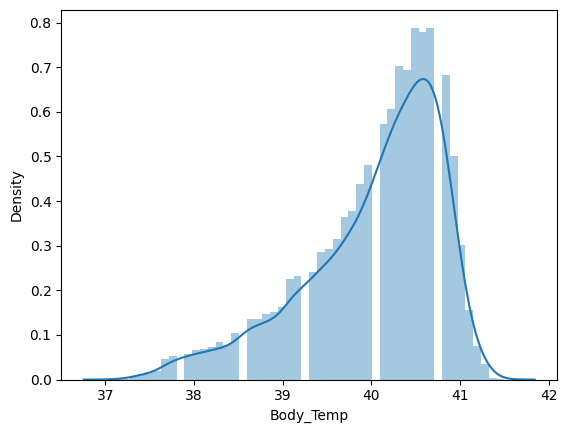

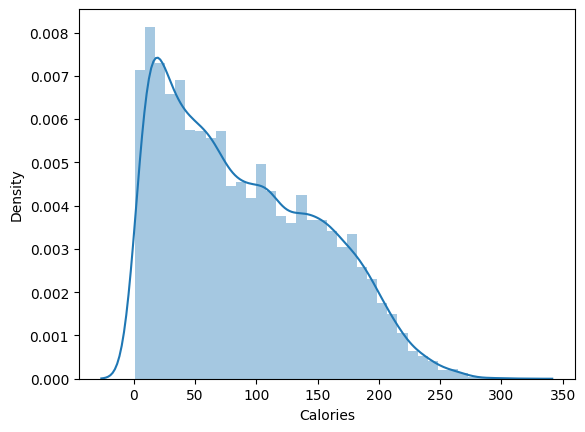

In [12]:
# histogram of each numric ccolumns

for i ,cols in enumerate(numeric_df.columns):
    plt.figure(i)
    sns.distplot(numeric_df[cols])

<Axes: >

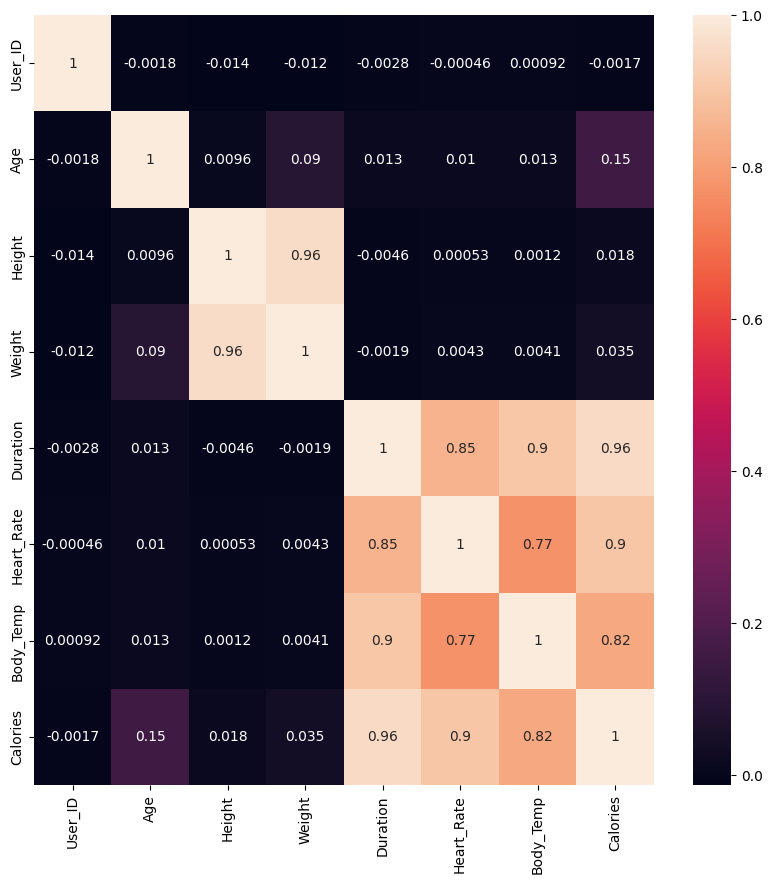

In [13]:
# co-relation heat map
plt.figure(figsize=(10,10))
corr=numeric_df.corr()
sns.heatmap(corr,annot=True)

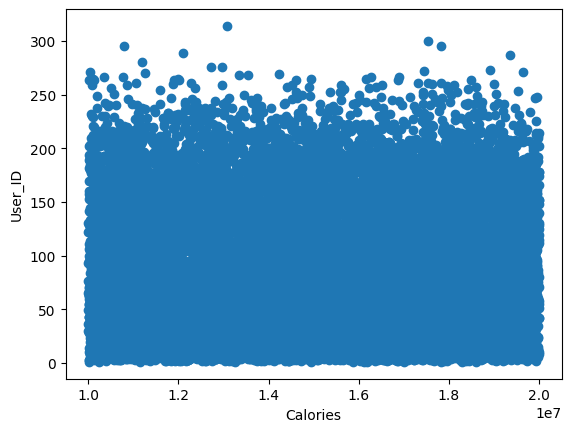

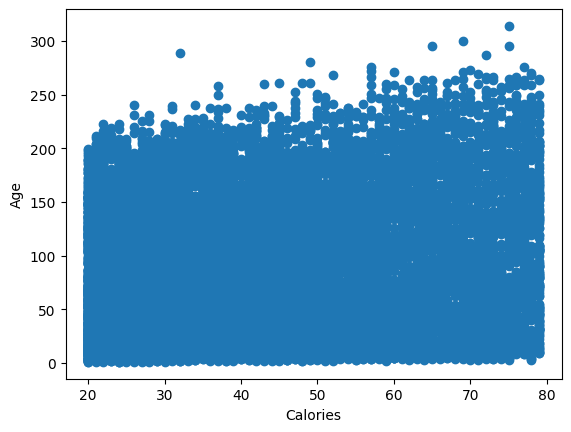

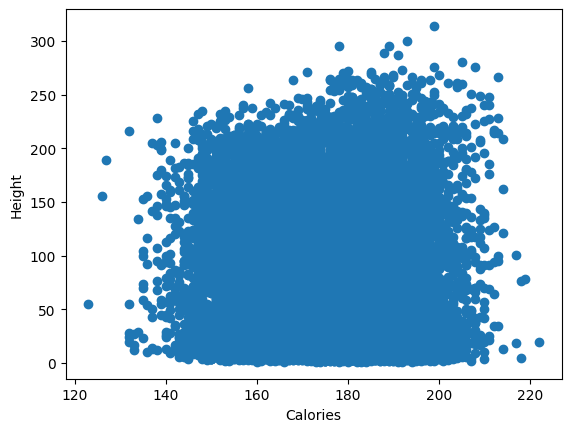

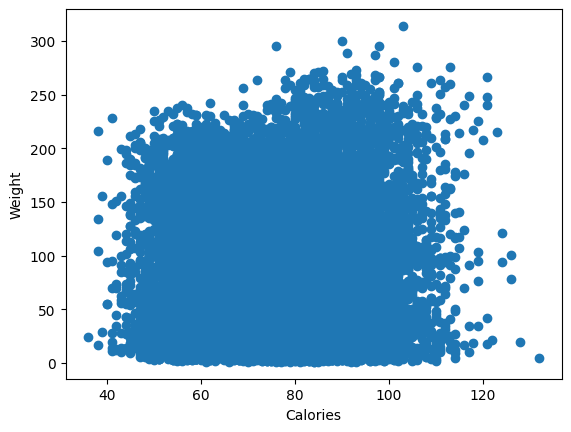

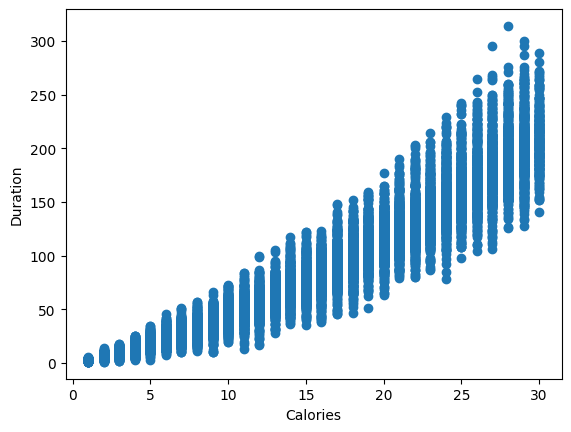

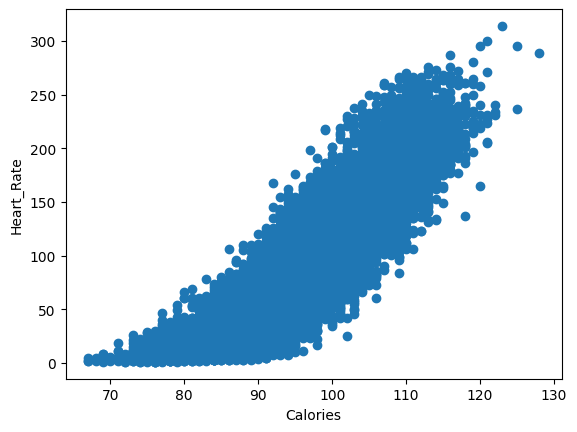

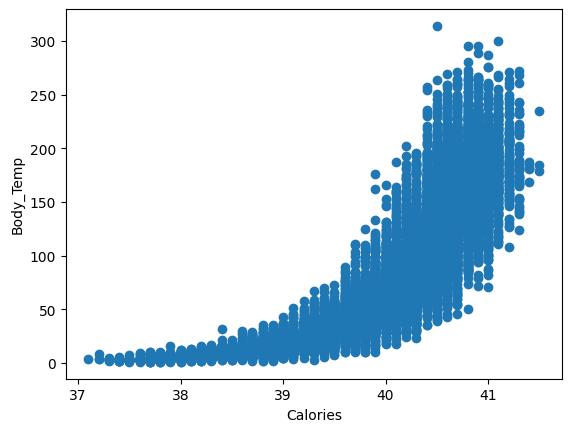

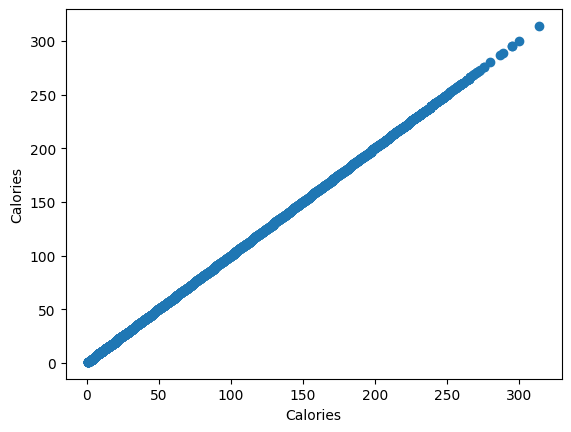

In [14]:
# Scatterplots vs target (Calories)

for i,cols in enumerate(numeric_df.columns):
    plt.figure(i)
    plt.scatter(numeric_df[cols],df[target])
    plt.xlabel(target)
    plt.ylabel(cols)

plt.show()

In [15]:
# removing unnecessary features (columns)
df.drop(['User_ID',],axis=1,inplace=True)

In [16]:
X=df.drop(target,axis=1)
y=df[target]

**Preprocessing**

In [17]:
# 2. Identify column types automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical features: {num_cols}")
print(f"Categorical features: {cat_cols}")

Numerical features: ['Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']
Categorical features: ['Gender']


In [18]:
num_tranformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

cat_tranformer=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('onehot',OneHotEncoder(handle_unknown='ignore'))
])

preprocessor=ColumnTransformer([
    ('num',num_tranformer,num_cols),
    ('cat',cat_tranformer,cat_cols)
])

In [19]:
X_processed=preprocessor.fit_transform(X)

# get the new tranformed feattures
new_feature_names = num_cols + list(
    preprocessor.named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
)
X_processed_df = pd.DataFrame(X_processed, columns=new_feature_names)

In [20]:
X_processed_df



,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender_female,Gender_male
0,1.484726,1.089582,1.265909,1.619127,0.989404,0.994023,0.0,1.0
1,-1.342179,-0.593726,-0.995458,-0.183990,-0.158461,0.352342,1.0,0.0
2,1.543620,0.318066,0.268247,-1.265861,-0.784569,-1.701035,0.0,1.0
3,-0.517665,0.318066,-0.263839,-0.304198,0.467647,0.609015,1.0,0.0
4,-0.929922,-1.435380,-1.128480,-0.664821,-1.515029,-0.289338,1.0,0.0
...,...,...,...,...,...,...,...,...
14995,-1.342179,1.299996,0.733822,-0.544614,-0.367164,0.480679,1.0,0.0
14996,-0.929922,-0.663864,-0.662904,-1.145653,-1.097623,-1.059355,1.0,0.0
14997,0.012379,-1.084691,-1.128480,0.056426,-0.575866,0.095670,1.0,0.0
14998,2.073665,1.299996,1.465441,-1.626484,-1.201975,-2.214380,0.0,1.0


**Modeling**

In [21]:
# split the data
X_train,X_test,y_train,y_test=train_test_split(X_processed_df,y,test_size=0.2,random_state=42)

In [22]:
# objective function
def objective(trial,X,y):
  # suggest the model type itself as hyperparamter
  model_type=trial.suggest_categorical('model_type',['xgboost','Lasso','randomforest'])
  # define model specific hyperparamters
  if model_type=='xgboost':
    params={
        'n_estimators':trial.suggest_int('n_estimators',100,1000),
        'learning_rate':trial.suggest_float('learning_rate',0.001,1.0),
        'max_depth':trial.suggest_int('max_depth',2,10),
        'min_child_weight':trial.suggest_int('min_child_weight',1,10),
        'subsample':trial.suggest_float('subsample',0.5,1.0),
        "n_jobs": -1,
        "random_state": 42,
    }
    model = xgb.XGBRegressor(**params)
  elif model_type=='Lasso':
    params={
        'alpha':trial.suggest_float('alpha',0.001,1.0),
        "random_state":42,
        "max_iter":trial.suggest_int('max_iter',100,1000)
    }
    model = Lasso(**params)
  elif model_type ==  'randomforest':
    params={
        'n_estimators':trial.suggest_int('n_estimators',100,1000),
        'max_depth':trial.suggest_int('max_depth',2,10),
        'min_samples_split':trial.suggest_int('min_samples_split',2,10),
        'min_samples_leaf':trial.suggest_int('min_samples_leaf',1,5),
        "n_jobs": -1,
        "random_state": 42,
    }
    model=RandomForestRegressor(**params)
  else:
    raise ValueError("Invalid model type")
  # Evaluate using cross-validation
  scores = cross_val_score(
      model, X, y, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1
  )
  mae = -scores.mean()

  return mae




In [23]:
# running the study
study=optuna.create_study(direction='minimize')
study.optimize(lambda trial:objective(trial,X_train,y_train),n_trials=100)
print("Best model and parameters:", study.best_params)
print("Best MAE:", study.best_value)

[I 2026-08-22 09:54:47,510] A new study created in memory with name: no-name-a54428cf-4135-40c4-a305-789144bbf959
[I 2026-08-22 09:54:51,381] Trial 0 finished with value: 8.312301204395988 and parameters: {'model_type': 'Lasso', 'alpha': 0.026632574472053885, 'max_iter': 437}. Best is trial 0 with value: 8.312301204395988.
[I 2026-08-22 09:54:51,665] Trial 1 finished with value: 8.74490409651629 and parameters: {'model_type': 'Lasso', 'alpha': 0.8076740157905201, 'max_iter': 304}. Best is trial 0 with value: 8.312301204395988.
[I 2026-08-22 09:54:51,869] Trial 2 finished with value: 8.713628480331234 and parameters: {'model_type': 'Lasso', 'alpha': 0.7827626966606873, 'max_iter': 710}. Best is trial 0 with value: 8.312301204395988.
[I 2026-08-22 09:54:52,058] Trial 3 finished with value: 8.856341209186315 and parameters: {'model_type': 'Lasso', 'alpha': 0.8896054318631165, 'max_iter': 836}. Best is trial 0 with value: 8.312301204395988.
[I 2026-08-22 09:54:52,180] Trial 4 finished with

Best model and parameters: {'model_type': 'xgboost', 'n_estimators': 838, 'learning_rate': 0.0248965177981193, 'max_depth': 10, 'min_child_weight': 8, 'subsample': 0.5322636695289946}
Best MAE: 0.8687276975220689


In [29]:
study.best_params

{'model_type': 'xgboost',
 'n_estimators': 838,
 'learning_rate': 0.0248965177981193,
 'max_depth': 10,
 'min_child_weight': 8,
 'subsample': 0.5322636695289946}

In [30]:
finalmodel=xgb.XGBRegressor(n_estimators=829,max_depth=5,min_child_weight=1,subsample=0.7558250157248468,n_jobs=-1,random_state=42,learning_rate=0.08912070493753241)
#
y_train_log = np.log1p(y_train)
# train model on y_train_log
finalmodel.fit(X_train, y_train_log)
# then when predicting:
y_pred = np.expm1(finalmodel.predict(X_test))


In [31]:
# r2 and rmse
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 1.3956188525633155
RMSE: 1.1813631332335184
R2: 0.9996541895535481


**Evaluation**

In [32]:
print(y_test.describe())
print(f"RMSE as % of mean: {(rmse / y_test.mean()) * 100:.2f}%")

count    3000.00000
mean       91.31600
std        63.53847
min         1.00000
25%        35.00000
50%        82.00000
75%       140.00000
max       295.00000
Name: Calories, dtype: float64
RMSE as % of mean: 1.29%


In [38]:
X_train


,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Gender_female,Gender_male
9839,-0.340984,0.318066,0.135225,-1.025445,-1.515029,-0.674346,0.0,1.0
9680,-1.165498,1.440271,0.800333,1.258504,1.511161,0.609015,0.0,1.0
7093,-0.576559,0.458341,0.135225,-0.424406,-0.784569,0.095670,0.0,1.0
11293,1.366938,-1.295105,-1.394523,-0.785029,-1.932434,-0.674346,1.0,0.0
820,-0.635453,-2.136759,-1.727077,-1.265861,-0.575866,-1.316027,1.0,0.0
...,...,...,...,...,...,...,...,...
5191,1.896983,-1.856207,-1.594055,0.777672,0.885053,0.737351,1.0,0.0
13418,-1.283285,-0.172899,-0.529883,0.537257,0.885053,0.865687,1.0,0.0
5390,0.836894,1.019444,1.132887,-0.905237,-0.575866,-0.674346,0.0,1.0
860,-0.458771,-0.032623,0.068715,-0.424406,0.154593,0.224006,0.0,1.0


Calories      1.000000
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Height        0.017537
Name: Calories, dtype: float64
Train R²: 0.9998191634427581
Test R²: 0.9996541895535481


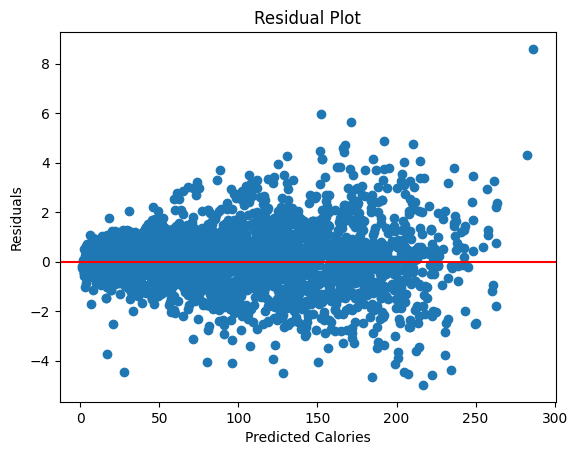

In [40]:

# 2. Check feature correlations with target
print(df.corr(numeric_only=True)['Calories'].sort_values(ascending=False))
# If any single feature has corr > 0.98, investigate if it's a proxy/leak

# 3. Residual plot — should look like random noise, no pattern
# Correct predictions on both sets
y_pred_train = np.expm1(finalmodel.predict(X_train))
y_pred_test = np.expm1(finalmodel.predict(X_test))

print(f"Train R²: {r2_score(y_train, y_pred_train)}")
print(f"Test R²: {r2_score(y_test, y_pred_test)}")

# Residual plot — use the real-scale predictions
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()